
========== MOTION ANALYSIS ==========
Total Frames         : 1268
Video FPS            : 59.94
Total Time           : 21.15 seconds
Average Displacement : 0.27 pixels/frame
Maximum Displacement : 9.81 pixels/frame
Average Direction    : 3.63 degrees
Average Velocity     : 16.03 pixels/second


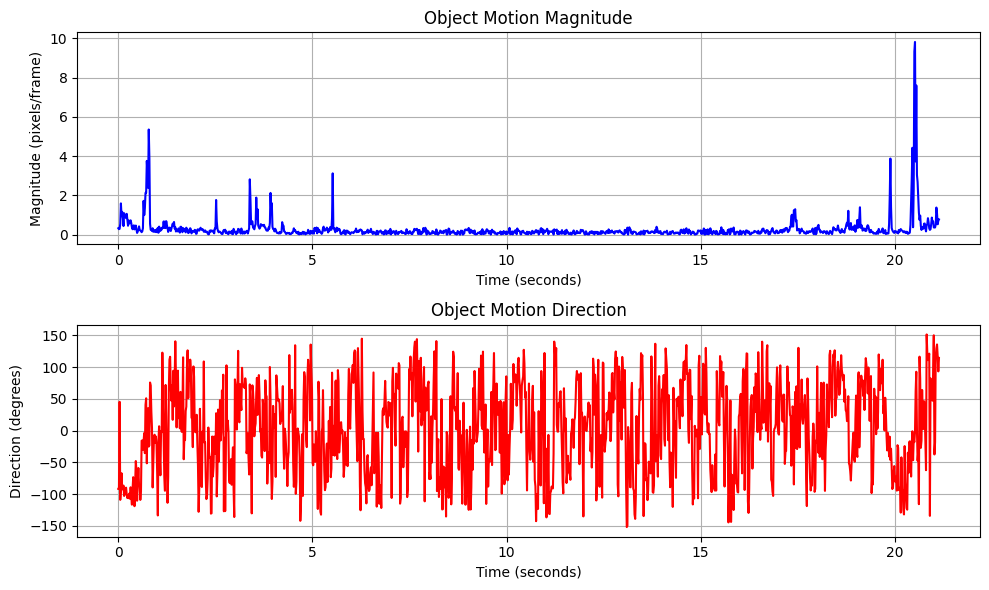


Program completed successfully.
Processed video saved as: optical_flow_output.mp4


In [11]:
# EXPERIMENT NO. 8
# Application of Optical Flow for Real-Time Object Tracking and Motion Analysis

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. IMPORT REQUIRED LIBRARIES AND LOAD VIDEO

VIDEO_PATH = "bird.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    print("Error: Unable to open video.")
    raise SystemExit

fps = cap.get(cv2.CAP_PROP_FPS)

if fps <= 0:
    fps = 30.0

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

ret, first_frame = cap.read()

if not ret:
    print("Error: Unable to read video.")
    cap.release()
    raise SystemExit

first_gray = cv2.cvtColor(
    first_frame,
    cv2.COLOR_BGR2GRAY
)

# 2. SHI-TOMASI CORNER DETECTION

feature_params = {
    "maxCorners": 100,
    "qualityLevel": 0.3,
    "minDistance": 7,
    "blockSize": 7
}

p0 = cv2.goodFeaturesToTrack(
    first_gray,
    mask=None,
    **feature_params
)

# 3. LUCAS-KANADE OPTICAL FLOW PARAMETERS

lk_params = {
    "winSize": (15, 15),
    "maxLevel": 2,
    "criteria": (
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
}

# 4. TRAJECTORY AND MOTION VARIABLES

trajectory_mask = np.zeros_like(first_frame)

prev_gray = first_gray.copy()

total_displacement = 0
frame_count = 0

motion_values = []
direction_values = []

# OUTPUT VIDEO

output_path = "optical_flow_output.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = None

# 5. PROCESS VIDEO FRAME BY FRAME

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    # LUCAS-KANADE OPTICAL FLOW

    if p0 is not None and len(p0) > 0:

        p1, status, error = cv2.calcOpticalFlowPyrLK(
            prev_gray,
            gray,
            p0,
            None,
            **lk_params
        )

        if p1 is not None and status is not None:

            status = status.ravel()

            good_new = p1[status == 1]
            good_old = p0[status == 1]

            # Convert points to shape (N, 2)
            good_new = good_new.reshape(-1, 2)
            good_old = good_old.reshape(-1, 2)

            magnitudes = []
            directions = []

            # DRAW TRAJECTORIES AND MOTION VECTORS

            for new, old in zip(
                good_new,
                good_old
            ):

                x_new, y_new = new
                x_old, y_old = old

                dx = x_new - x_old
                dy = y_new - y_old

                magnitude = np.sqrt(
                    dx ** 2 + dy ** 2
                )

                direction = np.degrees(
                    np.arctan2(dy, dx)
                )

                magnitudes.append(
                    magnitude
                )

                directions.append(
                    direction
                )

                total_displacement += magnitude

                # Draw trajectory

                trajectory_mask = cv2.line(
                    trajectory_mask,
                    (int(x_old), int(y_old)),
                    (int(x_new), int(y_new)),
                    (0, 255, 0),
                    2
                )

                # Draw displacement vector

                frame = cv2.arrowedLine(
                    frame,
                    (int(x_old), int(y_old)),
                    (int(x_new), int(y_new)),
                    (0, 0, 255),
                    2,
                    tipLength=0.3
                )

                # Draw feature point

                frame = cv2.circle(
                    frame,
                    (int(x_new), int(y_new)),
                    4,
                    (255, 0, 0),
                    -1
                )

            # MOTION ANALYSIS

            if len(magnitudes) > 0:

                avg_magnitude = np.mean(
                    magnitudes
                )

                avg_direction = np.mean(
                    directions
                )

                motion_values.append(
                    avg_magnitude
                )

                direction_values.append(
                    avg_direction
                )

                # Calculate X and Y displacement

                displacement_x = np.mean(
                    good_new[:, 0] -
                    good_old[:, 0]
                )

                displacement_y = np.mean(
                    good_new[:, 1] -
                    good_old[:, 1]
                )

                # Calculate velocity

                velocity = (
                    avg_magnitude * fps
                )

                # Display motion information

                cv2.putText(
                    frame,
                    f"Displacement: "
                    f"{avg_magnitude:.2f} pixels",
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 255),
                    2
                )

                cv2.putText(
                    frame,
                    f"Direction: "
                    f"{avg_direction:.2f} deg",
                    (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 255),
                    2
                )

                cv2.putText(
                    frame,
                    f"Velocity: "
                    f"{velocity:.2f} pixels/sec",
                    (10, 90),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 255),
                    2
                )

                cv2.putText(
                    frame,
                    f"dx: {displacement_x:.2f}, "
                    f"dy: {displacement_y:.2f}",
                    (10, 120),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 255),
                    2
                )

            # Update tracked points

            if len(good_new) > 0:

                p0 = good_new.reshape(
                    -1, 1, 2
                )

            else:

                p0 = None

        else:

            p0 = None

    # COMBINE FRAME WITH TRAJECTORY

    output = cv2.add(
        frame,
        trajectory_mask
    )

    # FARNEBACK DENSE OPTICAL FLOW

    flow = cv2.calcOpticalFlowFarneback(
        prev_gray,
        gray,
        None,
        0.5,
        3,
        15,
        3,
        5,
        1.2,
        0
    )

    flow_magnitude, flow_angle = cv2.cartToPolar(
        flow[..., 0],
        flow[..., 1]
    )

    # Create HSV representation

    hsv = np.zeros_like(frame)

    hsv[..., 0] = (
        flow_angle * 180 / np.pi / 2
    ).astype(np.uint8)

    hsv[..., 1] = 255

    hsv[..., 2] = cv2.normalize(
        flow_magnitude,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    dense_flow = cv2.cvtColor(
        hsv,
        cv2.COLOR_HSV2BGR
    )

    dense_flow = cv2.resize(
        dense_flow,
        (width, height)
    )

    # COMBINE LUCAS-KANADE AND FARNEBACK OUTPUT

    combined_output = np.hstack(
        (
            output,
            dense_flow
        )
    )

    # Create video writer

    if out is None:

        combined_height, combined_width = (
            combined_output.shape[:2]
        )

        out = cv2.VideoWriter(
            output_path,
            fourcc,
            fps,
            (
                combined_width,
                combined_height
            )
        )

    out.write(
        combined_output
    )

    # UPDATE PREVIOUS FRAME

    prev_gray = gray.copy()

    frame_count += 1

    # RE-DETECT FEATURES IF TOO FEW REMAIN

    if p0 is None or len(p0) < 10:

        p0 = cv2.goodFeaturesToTrack(
            gray,
            mask=None,
            **feature_params
        )

        trajectory_mask = np.zeros_like(
            frame
        )

# 6. RELEASE VIDEO

cap.release()

if out is not None:
    out.release()

# 7. MOTION ANALYSIS

if len(motion_values) > 0:

    average_displacement = np.mean(
        motion_values
    )

    maximum_displacement = np.max(
        motion_values
    )

    average_direction = np.mean(
        direction_values
    )

    total_time = frame_count / fps

    average_velocity = (
        average_displacement * fps
    )

    print(
        "\n========== MOTION ANALYSIS =========="
    )

    print(
        f"Total Frames         : "
        f"{frame_count}"
    )

    print(
        f"Video FPS            : "
        f"{fps:.2f}"
    )

    print(
        f"Total Time           : "
        f"{total_time:.2f} seconds"
    )

    print(
        f"Average Displacement : "
        f"{average_displacement:.2f} pixels/frame"
    )

    print(
        f"Maximum Displacement : "
        f"{maximum_displacement:.2f} pixels/frame"
    )

    print(
        f"Average Direction    : "
        f"{average_direction:.2f} degrees"
    )

    print(
        f"Average Velocity     : "
        f"{average_velocity:.2f} pixels/second"
    )

else:

    print("No motion was detected.")

# 8. DISPLAY MOTION GRAPHS

if len(motion_values) > 0:

    time_axis = (
        np.arange(
            len(motion_values)
        ) / fps
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.subplot(
        2, 1, 1
    )

    plt.plot(
        time_axis,
        motion_values,
        color="blue"
    )

    plt.title(
        "Object Motion Magnitude"
    )

    plt.xlabel(
        "Time (seconds)"
    )

    plt.ylabel(
        "Magnitude (pixels/frame)"
    )

    plt.grid()

    plt.subplot(
        2, 1, 2
    )

    plt.plot(
        time_axis,
        direction_values,
        color="red"
    )

    plt.title(
        "Object Motion Direction"
    )

    plt.xlabel(
        "Time (seconds)"
    )

    plt.ylabel(
        "Direction (degrees)"
    )

    plt.grid()

    plt.tight_layout()

    plt.show()

# 9. PROGRAM FINISHED

print(
    "\nProgram completed successfully."
)

print(
    f"Processed video saved as: "
    f"{output_path}"
)
